Link video:  https://drive.google.com/file/d/1nLC1OWULBblQdruRJP85Tui6JTDsJUA1/view?usp=drivesdk  
Link streamlit: https://student-placement-salary-2802392122.streamlit.app/

# Import Library

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [89]:
df = pd.read_csv('B.csv',delimiter=',')

In [90]:
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [91]:
df.shape

(5000, 18)

In [92]:
df.columns

Index(['student_id', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'cgpa', 'entrance_exam_score',
       'technical_skill_score', 'soft_skill_score', 'internship_count',
       'live_projects', 'work_experience_months', 'certifications',
       'attendance_percentage', 'backlogs', 'extracurricular_activities',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

# Data Validation & Problem Detection

In [94]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [95]:
print("Missing Values:")
print(df.isnull().sum(), "\n")

Missing Values:
student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64 



## Correlation Analysis

### Placement Outcomes (Numeric)

In [96]:
corr_placement = df.corr(numeric_only=True)['placement_status'].sort_values(ascending=False)
print(corr_placement)

placement_status          1.000000
salary_package_lpa        0.923552
cgpa                      0.278728
technical_skill_score     0.246573
soft_skill_score          0.197685
student_id                0.023910
work_experience_months    0.021453
hsc_percentage            0.017378
internship_count          0.011075
certifications            0.007517
entrance_exam_score       0.000937
ssc_percentage           -0.000030
live_projects            -0.001519
attendance_percentage    -0.012050
degree_percentage        -0.012085
backlogs                 -0.401394
Name: placement_status, dtype: float64


### Placement Outcomes (Categorical)

In [97]:
for col in df.select_dtypes(include='object').columns:
    print(df.groupby(col)['placement_status'].mean(), "\n")

gender
Female    0.170272
Male      0.176118
Name: placement_status, dtype: float64 

extracurricular_activities
No     0.179788
Yes    0.166326
Name: placement_status, dtype: float64 



#### Numerical Analysis
* salary_package_lpa (0.923) memiliki korelasi sangat tinggi terhadap placement. Hal ini wajar karena mahasiswa yang mendapatkan placement cenderung memiliki salary, sehingga kedua variabel ini saling berkaitan erat.
* CGPA (0.279), technical_skill_score (0.247), dan soft_skill_score (0.198) menunjukkan korelasi positif terhadap placement. Hal ini menunjukkan bahwa performa akademik dan keterampilan meningkatkan peluang mendapatkan pekerjaan.
* backlogs (-0.401) memiliki korelasi negatif yang cukup kuat, yang berarti semakin banyak backlog, semakin kecil kemungkinan mahasiswa mendapatkan placement.
* Variabel lain seperti work_experience_months, internship_count, dan certifications memiliki korelasi yang sangat rendah, sehingga tidak memberikan pengaruh signifikan terhadap placement.

#### Categorical Analysis
* Gender
  * Female: 0.170
  * Male: 0.176

Perbedaan sangat kecil, sehingga gender tidak memiliki pengaruh signifikan terhadap peluang placement.
* Extracurricular Activities
  * No: 0.180
  * Yes: 0.166

Perbedaan kecil, menunjukkan bahwa kegiatan ekstrakurikuler tidak memberikan pengaruh signifikan terhadap placement.


### Salary (Numerical)

In [98]:
corr_salary = df.corr(numeric_only=True)['salary_package_lpa'].sort_values(ascending=False)
print(corr_salary, "\n")

salary_package_lpa        1.000000
placement_status          0.923552
cgpa                      0.249022
technical_skill_score     0.223200
soft_skill_score          0.182165
student_id                0.027633
work_experience_months    0.013853
hsc_percentage            0.012632
internship_count          0.003564
entrance_exam_score      -0.001009
ssc_percentage           -0.002207
certifications           -0.003365
live_projects            -0.003859
degree_percentage        -0.009829
attendance_percentage    -0.014698
backlogs                 -0.376909
Name: salary_package_lpa, dtype: float64 



### Salary (Categorical)

In [99]:
for col in df.select_dtypes(include='object').columns:
    print(df.groupby(col)['salary_package_lpa'].mean(), "\n")

gender
Female    1.556595
Male      1.635060
Name: salary_package_lpa, dtype: float64 

extracurricular_activities
No     1.634078
Yes    1.556048
Name: salary_package_lpa, dtype: float64 



#### Numerical Analysis
* placement_status memiliki korelasi sangat tinggi (0.923) terhadap salary, yang menunjukkan bahwa mahasiswa yang mendapatkan placement cenderung memiliki salary lebih tinggi. Namun, variabel ini berpotensi menyebabkan data leakage.
* CGPA (0.249), technical_skill_score (0.223), dan soft_skill_score (0.182) memiliki korelasi positif terhadap salary. Hal ini menunjukkan bahwa performa akademik dan keterampilan berkontribusi terhadap salary, meskipun pengaruhnya tidak dominan.
* backlogs (-0.377) memiliki korelasi negatif yang cukup signifikan, yang berarti semakin banyak backlog, semakin rendah salary yang diperoleh.
* Variabel lain seperti internship_count, certifications, dan entrance_exam_score memiliki korelasi yang sangat rendah (mendekati nol), sehingga tidak menunjukkan pengaruh signifikan terhadap salary.

#### Categorical Analysis
* Gender
  * Male: 1.635
  * Female: 1.557

Perbedaan relatif kecil, sehingga gender tidak memiliki pengaruh signifikan terhadap salary.
* Extracurricular Activities
  * No: 1.634
  * Yes: 1.556

Perbedaan juga kecil, menunjukkan bahwa aktivitas ekstrakurikuler tidak memberikan pengaruh signifikan terhadap salary.

## Check Outliers

In [100]:
cols = df.select_dtypes(include='number').columns.drop([
    'student_id', 'placement_status', 'salary_package_lpa'
])

outliers = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outliers[col] = outlier_count

outliers

{'ssc_percentage': 0,
 'hsc_percentage': 0,
 'degree_percentage': 0,
 'cgpa': 0,
 'entrance_exam_score': 0,
 'technical_skill_score': 0,
 'soft_skill_score': 0,
 'internship_count': 0,
 'live_projects': 0,
 'work_experience_months': 0,
 'certifications': 0,
 'attendance_percentage': 0,
 'backlogs': 0}

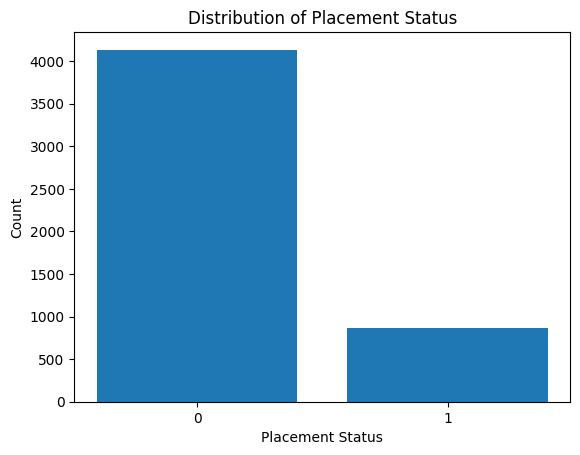

In [101]:
counts = df['placement_status'].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)

plt.title('Distribution of Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('Count')

plt.show()

Data placement status memiliki distribusi yang tidak seimbang (imbalanced), namun ketidakseimbangan tersebut tidak terlalu ekstrem sehingga tidak dilakukan penanganan khusus dan data tetap digunakan sebagaimana adanya.

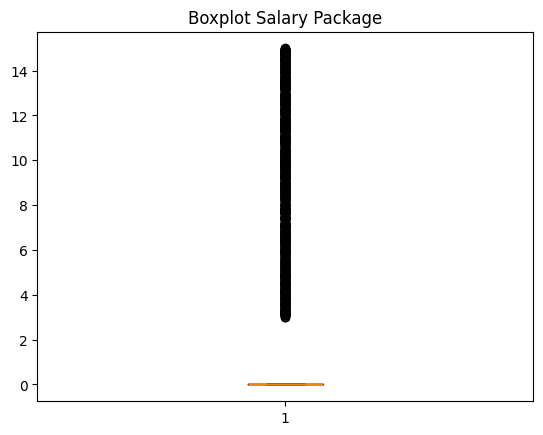

In [102]:
plt.figure()
plt.boxplot(df['salary_package_lpa'].dropna())
plt.title('Boxplot Salary Package')
plt.show()

Berdasarkan hasil outlier check, variabel salary_package_lpa menunjukkan adanya sejumlah data yang teridentifikasi sebagai outlier.

Hal ini disebabkan oleh distribusi data salary yang cenderung tidak merata dan memiliki nilai ekstrem di bagian atas (right-skewed). Dalam konteks data salary, nilai yang tinggi tidak selalu menunjukkan kesalahan atau anomali, melainkan dapat merepresentasikan variasi nyata dalam penawaran gaji.

Dengan demikian, meskipun secara statistik terdapat outlier, nilai-nilai tersebut tetap dipertahankan karena dianggap sebagai bagian dari distribusi data yang valid dan berpotensi memberikan informasi penting dalam proses modeling.

Oleh karena itu, tidak dilakukan penghapusan outlier pada variabel ini.

# Train Test Split

In [103]:
from sklearn.model_selection import train_test_split

x = df.drop(['placement_status','salary_package_lpa', 'student_id'], axis=1)
y_class = df['placement_status']
y_reg = df['salary_package_lpa']

x_train, x_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    x, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

Pada tahap pembagian data, digunakan parameter stratify untuk menjaga proporsi distribusi kelas antara data training dan data testing tetap konsisten dengan data asli. Hal ini penting terutama karena dataset memiliki class imbalance, sehingga model dapat dilatih dan dievaluasi secara lebih representatif.

In [104]:
print(x_train.shape, x_test.shape)
print(y_train_class.shape, y_test_class.shape)
print(y_train_reg.shape, y_test_reg.shape)

(4000, 15) (1000, 15)
(4000,) (1000,)
(4000,) (1000,)


# Data Preprocessing
Pada tahap preprocessing, digunakan pendekatan Pipeline dan ColumnTransformer untuk menangani perbedaan tipe fitur secara sistematis.

In [105]:
num_cols = x_train.select_dtypes(include=np.number).columns
cat_cols = x_train.select_dtypes(exclude=np.number).columns

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

#### StandardScaler untuk Fitur Numerik
Fitur numerik diproses menggunakan *StandardScaler* untuk melakukan standardisasi data, yaitu mengubah distribusi data sehingga memiliki rata-rata 0 dan standar deviasi 1.

Alasan penggunaan StandardScaler:
* Menghindari dominasi fitur dengan skala besar terhadap fitur lain
* Meningkatkan performa algoritma yang sensitif terhadap skala data, seperti Logistic Regression dan Linear Regression
* Membantu proses optimasi model menjadi lebih stabil dan cepat

#### OneHotEncoder untuk Fitur Kategorikal
Fitur kategorikal diproses menggunakan *OneHotEncoder* untuk mengubah data kategori menjadi representasi numerik dalam bentuk vektor biner.

Alasan penggunaan OneHotEncoder:
* Menghindari asumsi hubungan ordinal antar kategori (misalnya "Male" tidak lebih kecil atau lebih besar dari "Female")
* Membuat model dapat memahami setiap kategori sebagai entitas yang terpisah

Parameter *handle_unknown='ignore'* digunakan agar model tetap dapat menangani kategori baru pada data testing tanpa menghasilkan error.

Parameter *drop='if_binary'*, yang berarti jika suatu fitur hanya memiliki dua kategori (binary), maka salah satu hasil encoding akan dihapus, untuk menghindari redundansi informasi, karena dua kolom pada fitur biner sebenarnya membawa informasi yang sama, mengurangi risiko multicollinearity, terutama pada model seperti Logistic Regression dan Linear Regression, membuat jumlah fitur menjadi lebih efisien tanpa menghilangkan informasi penting.

In [107]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa',
       'entrance_exam_score', 'technical_skill_score', 'soft_skill_score',
       'internship_count', 'live_projects', 'work_experience_months',
       'certifications', 'attendance_percentage', 'backlogs'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 Index(['gender', 'extracurricular_activities'], dtype='object'))])

## Data Transformation

In [108]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

* `fit_transform(x_train)` digunakan pada data training untuk:
  * Mempelajari parameter dari data (misalnya mean dan standar deviasi pada StandardScaler)
  * Menerapkan transformasi seperti scaling dan encoding

* `transform(x_test)` digunakan pada data testing untuk:
  * Menerapkan transformasi yang sama seperti pada data training
  * Tidak melakukan pembelajaran ulang terhadap data testing

Pendekatan ini dilakukan untuk menghindari data leakage, yaitu kondisi di mana informasi dari data testing ikut mempengaruhi proses training. Jika transformasi dilakukan secara langsung pada seluruh data sebelum splitting, maka model dapat memperoleh informasi yang tidak seharusnya diketahui.

Dengan memisahkan proses *fit* dan *transform*, model hanya belajar dari data training, sehingga evaluasi pada data testing menjadi lebih valid dan representatif.

# Modeling

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC, SVR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

## Classification (Placement Status)

In [110]:
model_class = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC()
}

## Regression (Salary)

In [111]:
model_reg = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100,
                                           max_depth=10,
                                           min_samples_split=5,
                                           random_state=42),
    "Support Vector Machine": SVR()
}

# Training & Evaluation

## Classification (Placement Status)

In [112]:
results_class = []

for name, model in model_class.items():
    model.fit(x_train_processed, y_train_class)
    y_pred = model.predict(x_test_processed)

    results_class.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred),
        "Recall": recall_score(y_test_class, y_pred),
        "F1 Score": f1_score(y_test_class, y_pred)
    })

df_results_class = pd.DataFrame(results_class)
df_results_class

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.891,0.719178,0.606936,0.658307
1,Decision Tree,1.000,1.000000,1.000000,1.000000
2,Support Vector Machine,0.944,0.877419,0.786127,0.829268


Berdasarkan hasil evaluasi model klasifikasi, diperoleh perbandingan performa sebagai berikut:

* Logistic Regression memiliki Accuracy sebesar 0.891 dan F1 Score sebesar 0.658. Hal ini menunjukkan bahwa model cukup baik dalam melakukan klasifikasi, namun masih terdapat ketidakseimbangan antara Precision (0.719) dan Recall (0.607). Artinya, model belum optimal dalam menangkap seluruh data positif dan masih cenderung melewatkan beberapa kasus yang seharusnya terklasifikasi positif.
* Decision Tree menunjukkan performa sempurna dengan nilai Accuracy, Precision, Recall, dan F1 Score masing-masing sebesar 1.000. Meskipun terlihat sangat baik, performa yang terlalu sempurna ini perlu diwaspadai karena berpotensi menunjukkan overfitting, yaitu model terlalu menyesuaikan diri dengan data training sehingga kemungkinan kurang mampu melakukan generalisasi pada data baru.
* Support Vector Machine (SVM) memiliki Accuracy sebesar 0.944 dan F1 Score sebesar 0.829. Model ini menunjukkan keseimbangan yang baik antara Precision (0.877) dan Recall (0.786), sehingga lebih mampu mengidentifikasi data positif dengan lebih konsisten dibandingkan Logistic Regression. Selain itu, performanya yang tinggi namun tidak sempurna menunjukkan bahwa model ini memiliki kemampuan generalisasi yang lebih baik dibandingkan Decision Tree.

Secara keseluruhan, jika mempertimbangkan keseimbangan antara performa dan kemampuan generalisasi, Support Vector Machine (SVM) dapat dianggap sebagai model yang paling optimal pada kasus ini. Logistic Regression tetap berguna sebagai model baseline yang stabil, sedangkan Decision Tree perlu dievaluasi lebih lanjut (misalnya dengan cross-validation) untuk memastikan apakah performanya benar-benar konsisten atau hanya akibat overfitting.

Dilakukan perobaan dengan menambahkan parameter class_weight='balanced' pada model Support Vector Machine untuk menangani ketidakseimbangan kelas.
Hasil menunjukkan bahwa penggunaan class_weight meningkatkan nilai recall secara signifikan dari 0.79 menjadi 0.94, yang berarti model menjadi lebih
mampu mendeteksi kelas minoritas. Namun, peningkatan ini diikuti dengan penurunan precision dari 0.88 menjadi 0.72, yang menunjukkan adanya peningkatan kesalahan prediksi pada kelas mayoritas.

Berdasarkan hasil tersebut, model tanpa class_weight dipilih karena memiliki keseimbangan performa yang lebih baik secara keseluruhan.

Dengan class_weight='balanced':

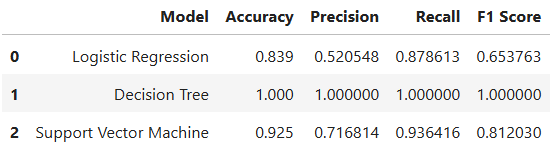

## Regression (Salary)

In [113]:
results_reg = []

for name, model in model_reg.items():
    model.fit(x_train_processed, y_train_reg)
    y_pred = model.predict(x_test_processed)

    results_reg.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "MSE": mean_squared_error(y_test_reg, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        "R2 Score": r2_score(y_test_reg, y_pred)
    })

df_results_reg = pd.DataFrame(results_reg)
df_results_reg

,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree,0.682140,4.287689,2.070674,0.704590
1,Random Forest,0.507219,2.069440,1.438555,0.857421
2,Support Vector Machine,1.423676,9.518056,3.085135,0.344232


Berdasarkan hasil evaluasi model regresi, diperoleh perbandingan performa sebagai berikut:

* Decision Tree memiliki MAE sebesar 0.682, MSE sebesar 4.288, RMSE sebesar 2.071, dan R2 Score sebesar 0.705. Hal ini menunjukkan bahwa model mampu menangkap pola data dengan cukup baik, meskipun tingkat error masih relatif lebih tinggi dibandingkan model terbaik.
* Random Forest menunjukkan performa terbaik dengan MAE sebesar 0.507, MSE sebesar 2.069, RMSE sebesar 1.439, serta R2 Score sebesar 0.857. Nilai error yang paling kecil dan R2 yang paling tinggi mengindikasikan bahwa model ini mampu memprediksi nilai dengan akurasi yang lebih baik serta menjelaskan variasi data dengan lebih optimal. Selain itu, sebagai model ensemble, Random Forest cenderung lebih stabil dan memiliki kemampuan generalisasi yang baik.
* Support Vector Machine (SVM) memiliki MAE sebesar 1.424, MSE sebesar 9.518, RMSE sebesar 3.085, dan R2 Score sebesar 0.344. Nilai error yang cukup besar serta R2 yang rendah menunjukkan bahwa model ini kurang mampu menangkap pola hubungan dalam data, sehingga performanya masih jauh di bawah model lainnya.

Secara keseluruhan, Random Forest dapat dianggap sebagai model terbaik pada kasus ini karena memiliki kombinasi error paling rendah dan kemampuan prediksi paling tinggi. Decision Tree masih dapat digunakan sebagai alternatif dengan performa yang cukup baik, sedangkan Support Vector Machine kurang direkomendasikan karena performanya yang relatif rendah dalam memodelkan data regresi ini.